In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import scipy.stats as stats
import seaborn as sns

In [2]:
data = pd.read_csv('data/train.csv')
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


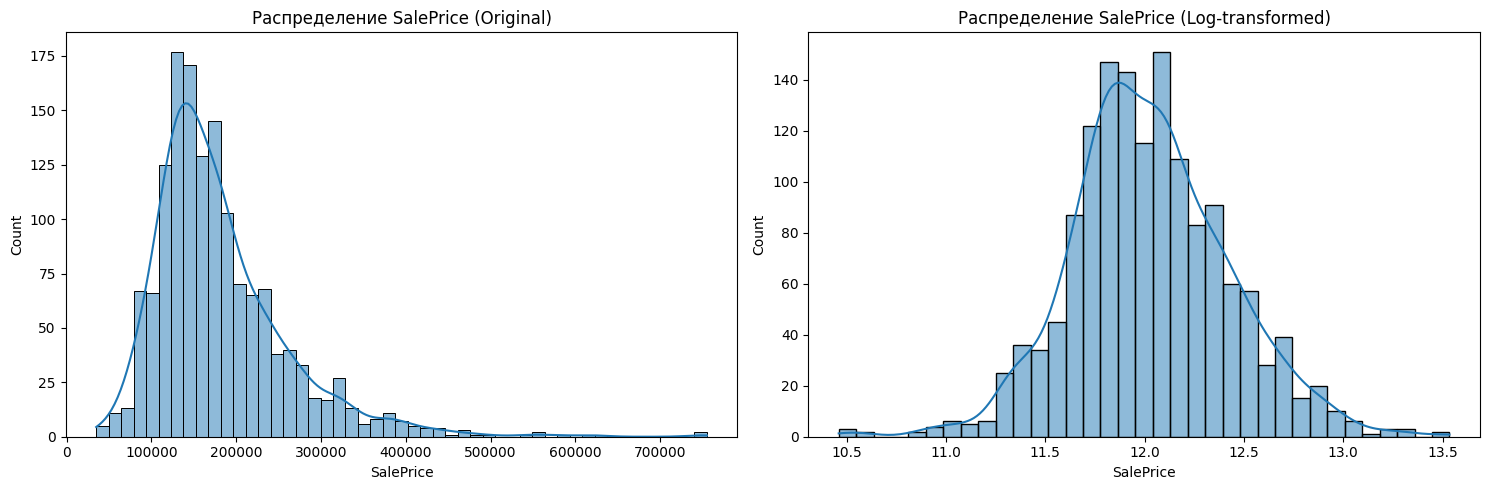

In [3]:
# 1. Проверка распределения целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Распределение SalePrice (Original)')

# Используем логарифм для сравнения
sns.histplot(np.log1p(data['SalePrice']), kde=True, ax=axes[1])
axes[1].set_title('Распределение SalePrice (Log-transformed)')

plt.tight_layout()
plt.show()

In [4]:
data['SalePrice'].skew()

np.float64(1.8828757597682129)

In [5]:
np.log1p(data['SalePrice']).skew()

np.float64(0.12134661989685333)

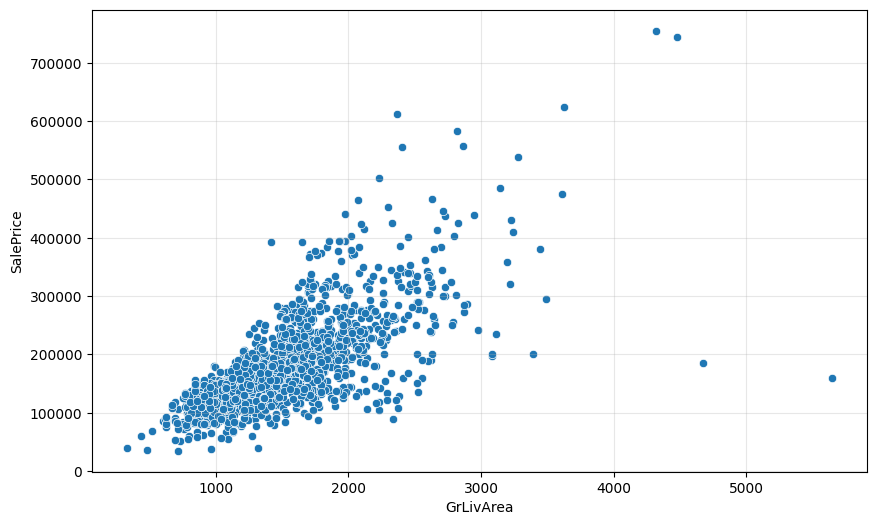

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=data)
plt.grid(True, alpha=0.3)
plt.show()

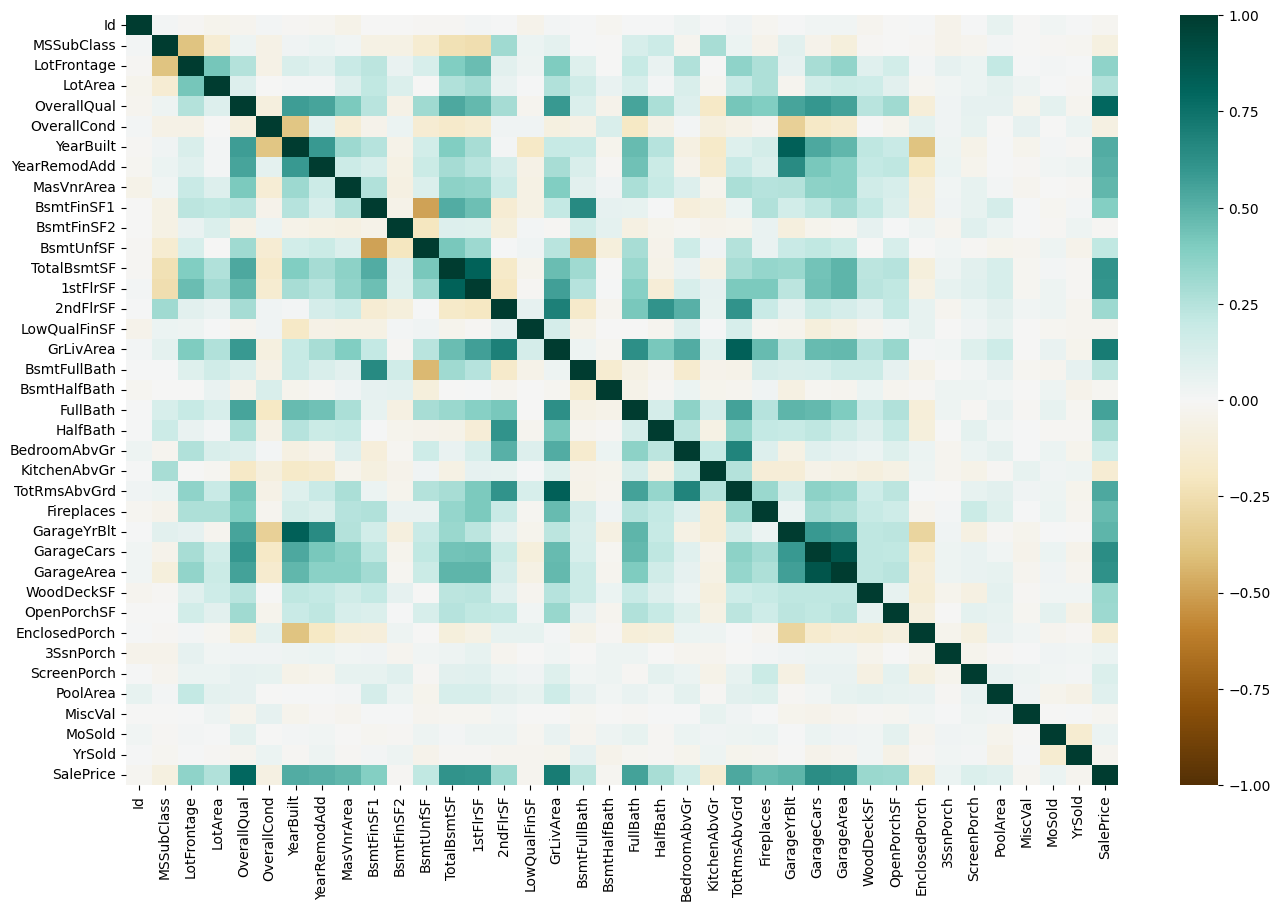

In [7]:
fig = plt.figure()

fig.set_size_inches(16,10)

sns.heatmap(data[data.select_dtypes(include=['number']).columns].corr(),
            xticklabels=data.select_dtypes(include=['number']).columns,
            yticklabels=data.select_dtypes(include=['number']).columns,
            cmap='BrBG',
            vmin=-1,
            vmax=1)

plt.show()

40


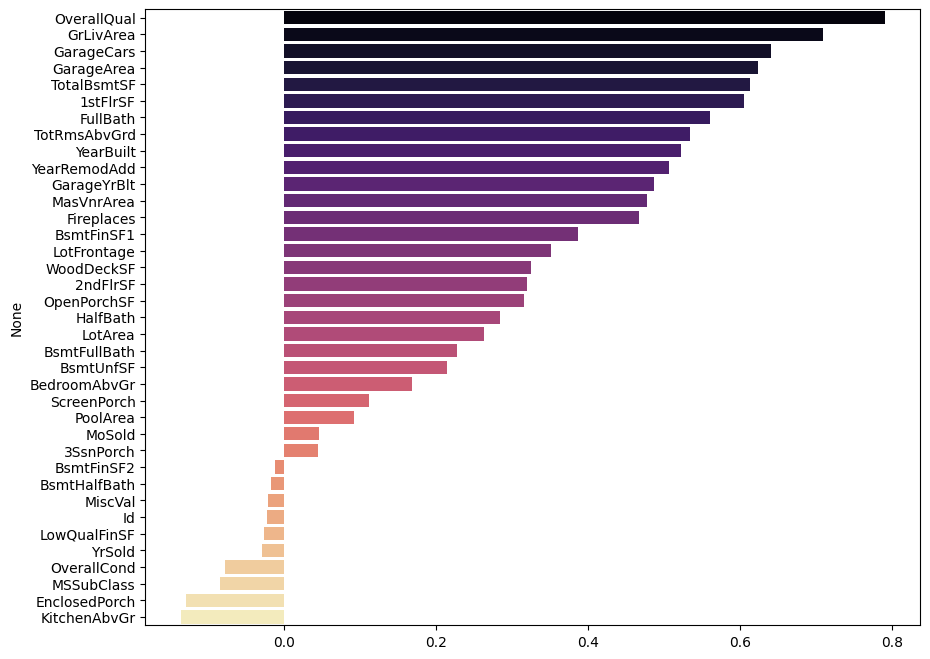

In [15]:
print(a)
plt.figure(figsize=(10, 8))
correlations = data[data.select_dtypes(include=['number']).columns].corrwith(data['SalePrice']).sort_values(ascending=False)
sns.barplot(x=correlations[1:round((data.shape[1])/2)].values, y=correlations[1:round((data.shape[1])/2)].index, hue=correlations[1:round((data.shape[1])/2)].index, palette='magma')
plt.show()